# Motor Observer (The Soft Sensor) - Digital Twin for Electrical Machines

## The Engineering Concept

Modern high-performance electrical machines (like PMSMs or heavy-duty DC motors) 
are pushed to their thermal limits to maximize torque density. However, measuring 
the internal rotor winding temperature directly is notoriously difficult, expensive, 
and prone to mechanical sensor failure. If the winding overheats, the insulation 
melts, causing catastrophic motor burnout.

This project implements a "Soft Sensor" (a Digital Twin) using a Physics-Informed 
Neural Network (PINN). Instead of relying on a physical temperature sensor, the 
PINN acts as a state observer. It reads the easily measurable external signals 
(Terminal Voltage and Phase Current) and uses the coupled Electro-Thermal 
Differential Equations to instantly "observe" and estimate the hidden internal 
rotor temperature in real-time.

### The Physics (Coupled Electro-Thermal Dynamics)

**1. Electrical Dynamics:**
```
V(t) = L*(di/dt) + R(T)*i(t) + K*w(t)
```
Where R(T) is temperature-dependent:
```
R(T) = R0 * (1 + alpha * (T(t) - T_amb))
```

**2. Thermal Dynamics:**
```
C_th*(dT/dt) = P_loss - (T(t) - T_amb)/R_th
```
Where Ohmic power loss:
```
P_loss = R(T) * i(t)^2
```

### System Outputs (Neural Network Predictions)

- **i_pred**: Estimated Current (Amperes)
- **T_pred**: Estimated Internal Temperature (Celsius) - The Hidden State!

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Physical Motor Parameters

In [2]:
# Electrical Parameters
L      = 0.05    # Inductance (Henries)
R0     = 1.2     # Base phase resistance at ambient temperature (Ohms)
alpha  = 0.00393 # Temperature coefficient of copper (1/Celsius)
K_e    = 0.1     # Back-EMF constant (V/(rad/s))

# Thermal Parameters
C_th   = 50.0    # Thermal capacitance of the rotor (J/Celsius) - Heat capacity
R_th   = 2.5     # Thermal resistance to environment (Celsius/Watt) - Cooling rate
T_amb  = 25.0    # Ambient environment temperature (Celsius)

print("Motor Physical Parameters:")
print("\nElectrical Parameters:")
print(f"  Inductance (L): {L} H")
print(f"  Base Resistance (R0): {R0} Ω")
print(f"  Temp Coefficient (α): {alpha} /°C")
print(f"  Back-EMF Constant (Ke): {K_e} V/(rad/s)")

print("\nThermal Parameters:")
print(f"  Thermal Capacitance (C_th): {C_th} J/°C")
print(f"  Thermal Resistance (R_th): {R_th} °C/W")
print(f"  Ambient Temperature (T_amb): {T_amb} °C")

Motor Physical Parameters:

Electrical Parameters:
  Inductance (L): 0.05 H
  Base Resistance (R0): 1.2 Ω
  Temp Coefficient (α): 0.00393 /°C
  Back-EMF Constant (Ke): 0.1 V/(rad/s)

Thermal Parameters:
  Thermal Capacitance (C_th): 50.0 J/°C
  Thermal Resistance (R_th): 2.5 °C/W
  Ambient Temperature (T_amb): 25.0 °C


## 2. The Physics-Informed Neural Network (Digital Twin)

In [3]:
class MotorDigitalTwinPINN(nn.Module):
    """
    Physics-Informed Neural Network for Motor Digital Twin
    
    This network acts as a soft sensor, estimating both the observable
    current and the hidden internal rotor temperature by enforcing
    the coupled electro-thermal physics.
    
    Input:
        t: [batch_size, 1] - Time in seconds
    
    Outputs:
        i_pred: [batch_size, 1] - Estimated current (Amperes)
        T_pred: [batch_size, 1] - Estimated rotor temperature (Celsius)
    """
    def __init__(self):
        super(MotorDigitalTwinPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2) 
        )
        
    def forward(self, t):
        out = self.net(t)
        i_pred = out[:, 0:1] * 20.0        # Scale output for current
        T_pred = T_amb + out[:, 1:2] * 100.0 # Scale output for temperature
        return i_pred, T_pred

# Display network architecture
pinn = MotorDigitalTwinPINN()
print("Network Architecture:")
print(pinn)
print(f"\nTotal Parameters: {sum(p.numel() for p in pinn.parameters()):,}")

Network Architecture:
MotorDigitalTwinPINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total Parameters: 8,578


## 3. Physics & Data Loss Formulation

In [4]:
def calculate_loss(pinn, t_collocation, t_data, V_data, w_data, i_data_measured):
    """
    Calculate the total loss combining data alignment and physics constraints.
    
    The loss consists of:
    1. Data loss: Ensures the network matches measured current sensor data
    2. Physics loss: Enforces the coupled electro-thermal differential equations
    
    Parameters:
        pinn: The neural network model
        t_collocation: Time points for physics evaluation
        t_data: Time points with sensor measurements
        V_data: Voltage measurements
        w_data: Speed measurements
        i_data_measured: Current sensor measurements
    
    Returns:
        total_loss, loss_data, loss_physics
    """
    # A. Data Loss (Sensor Alignment - Current Only)
    i_pred_data, _ = pinn(t_data)
    loss_data = torch.mean((i_pred_data - i_data_measured)**2)
    
    # B. Physics Loss (Electro-Thermal ODEs)
    t_collocation.requires_grad_(True)
    i_pred, T_pred = pinn(t_collocation)
    
    # Calculate derivatives
    di_dt = torch.autograd.grad(i_pred, t_collocation, 
                                grad_outputs=torch.ones_like(i_pred), 
                                create_graph=True)[0]
    dT_dt = torch.autograd.grad(T_pred, t_collocation, 
                                grad_outputs=torch.ones_like(T_pred), 
                                create_graph=True)[0]
    
    # Constant operating conditions
    V_input = 24.0  # Constant nominal voltage
    w_input = 100.0 # Constant speed
    
    # Temperature-dependent resistance
    R_t = R0 * (1.0 + alpha * (T_pred - T_amb))
    
    # Electrical dynamics residual
    electrical_residual = (L * di_dt) + (R_t * i_pred) + (K_e * w_input) - V_input
    
    # Thermal dynamics residual
    heat_generated = (i_pred**2) * R_t
    heat_dissipated = (T_pred - T_amb) / R_th
    thermal_residual = (C_th * dT_dt) - heat_generated + heat_dissipated
    
    loss_physics = torch.mean(electrical_residual**2) + torch.mean(thermal_residual**2)
    
    # Weighted total loss
    total_loss = (10.0 * loss_data) + (1.0 * loss_physics)
    
    return total_loss, loss_data, loss_physics

print("Loss function defined successfully!")
print("\nLoss Components:")
print("  - Data Loss: Aligns with current sensor measurements")
print("  - Physics Loss: Enforces electro-thermal ODEs")

Loss function defined successfully!

Loss Components:
  - Data Loss: Aligns with current sensor measurements
  - Physics Loss: Enforces electro-thermal ODEs


## 4. Training Setup

In [5]:
def train_motor_digital_twin():
    """
    Train the Motor Digital Twin PINN.
    
    The network learns to estimate both the observable current and
    the hidden internal temperature by combining sensor data with
    physics-informed constraints.
    
    Returns:
        Trained model, loss history, and data arrays
    """
    t_max = 600.0 # 10-minute heavy load cycle
    
    # Synthetic Sensor Data
    t_data_np = np.linspace(0, t_max, 200).reshape(-1, 1)
    i_steady_state = (24.0 - (K_e * 100.0)) / (R0 * 1.5) 
    i_data_measured_np = np.full_like(t_data_np, i_steady_state) 
    
    t_data = torch.tensor(t_data_np, dtype=torch.float32)
    i_data_measured = torch.tensor(i_data_measured_np, dtype=torch.float32)
    
    t_collocation_np = np.linspace(0, t_max, 1000).reshape(-1, 1)
    t_collocation = torch.tensor(t_collocation_np, dtype=torch.float32)

    V_data = torch.full_like(t_data, 24.0)
    w_data = torch.full_like(t_data, 100.0)

    pinn_digital_twin = MotorDigitalTwinPINN()
    optimizer = optim.Adam(pinn_digital_twin.parameters(), lr=1e-3)
    
    epochs = 5000
    
    # Tracking for Analysis
    history = {'total': [], 'data': [], 'phys': []}
    
    print("==========================================================")
    print("Initiating Motor Observer (Digital Twin) Training Phase...")
    print("==========================================================")
    print(f"\nTraining Configuration:")
    print(f"  Time Duration: {t_max} seconds ({t_max/60:.1f} minutes)")
    print(f"  Sensor Data Points: {len(t_data)}")
    print(f"  Collocation Points: {len(t_collocation)}")
    print(f"  Operating Voltage: {V_data[0].item()} V")
    print(f"  Operating Speed: {w_data[0].item()} rad/s")
    print(f"  Steady State Current: {i_steady_state:.2f} A")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss, loss_data, loss_phys = calculate_loss(pinn_digital_twin, t_collocation, 
                                                     t_data, V_data, w_data, 
                                                     i_data_measured)
        loss.backward()
        optimizer.step()
        
        history['total'].append(loss.item())
        history['data'].append(loss_data.item())
        history['phys'].append(loss_phys.item())
        
        if epoch % 1000 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:04d} | Total Loss: {loss.item():.6f} | Sensor Data: {loss_data.item():.6f} | Physics: {loss_phys.item():.6f}")

    return pinn_digital_twin, history, t_collocation_np, t_data_np, i_data_measured_np

print("Training function defined successfully!")

Training function defined successfully!


## 5. Training Execution

In [6]:
# Train the Motor Digital Twin
trained_pinn, loss_history, t_collocation, t_data, i_measured = train_motor_digital_twin()

Initiating Motor Observer (Digital Twin) Training Phase...

Training Configuration:
  Time Duration: 600.0 seconds (10.0 minutes)
  Sensor Data Points: 200
  Collocation Points: 1000
  Operating Voltage: 24.0 V
  Operating Speed: 100.0 rad/s
  Steady State Current: 7.78 A
Epoch 0000 | Total Loss: 2306.057861 | Sensor Data: 98.608719 | Physics: 1319.970703
Epoch 1000 | Total Loss: 15.216303 | Sensor Data: 1.272317 | Physics: 2.493132
Epoch 2000 | Total Loss: 13.625442 | Sensor Data: 1.071076 | Physics: 2.914683
Epoch 3000 | Total Loss: 13.167154 | Sensor Data: 0.848602 | Physics: 4.681139
Epoch 4000 | Total Loss: 11.927591 | Sensor Data: 0.857973 | Physics: 3.347859
Epoch 4999 | Total Loss: 11.789472 | Sensor Data: 0.805662 | Physics: 3.732853


## 6. Analysis & Results Visualization

In [7]:
print("\nGenerating Analysis Dashboard...")

# Generate continuous predictions for plotting
t_tensor = torch.tensor(t_collocation, dtype=torch.float32)
with torch.no_grad():
    i_pred, T_pred = trained_pinn(t_tensor)
    
i_pred_np = i_pred.numpy()
T_pred_np = T_pred.numpy()

print("\nPrediction Statistics:")
print(f"  Current Range: [{i_pred_np.min():.2f}, {i_pred_np.max():.2f}] A")
print(f"  Temperature Range: [{T_pred_np.min():.2f}, {T_pred_np.max():.2f}] °C")
print(f"  Max Temperature Rise: {T_pred_np.max() - T_amb:.2f} °C above ambient")


Generating Analysis Dashboard...

Prediction Statistics:
  Current Range: [6.66, 8.60] A
  Temperature Range: [35.19, 292.39] °C
  Max Temperature Rise: 267.39 °C above ambient



Visualization saved as 'motor_observer_digital_twin.png'


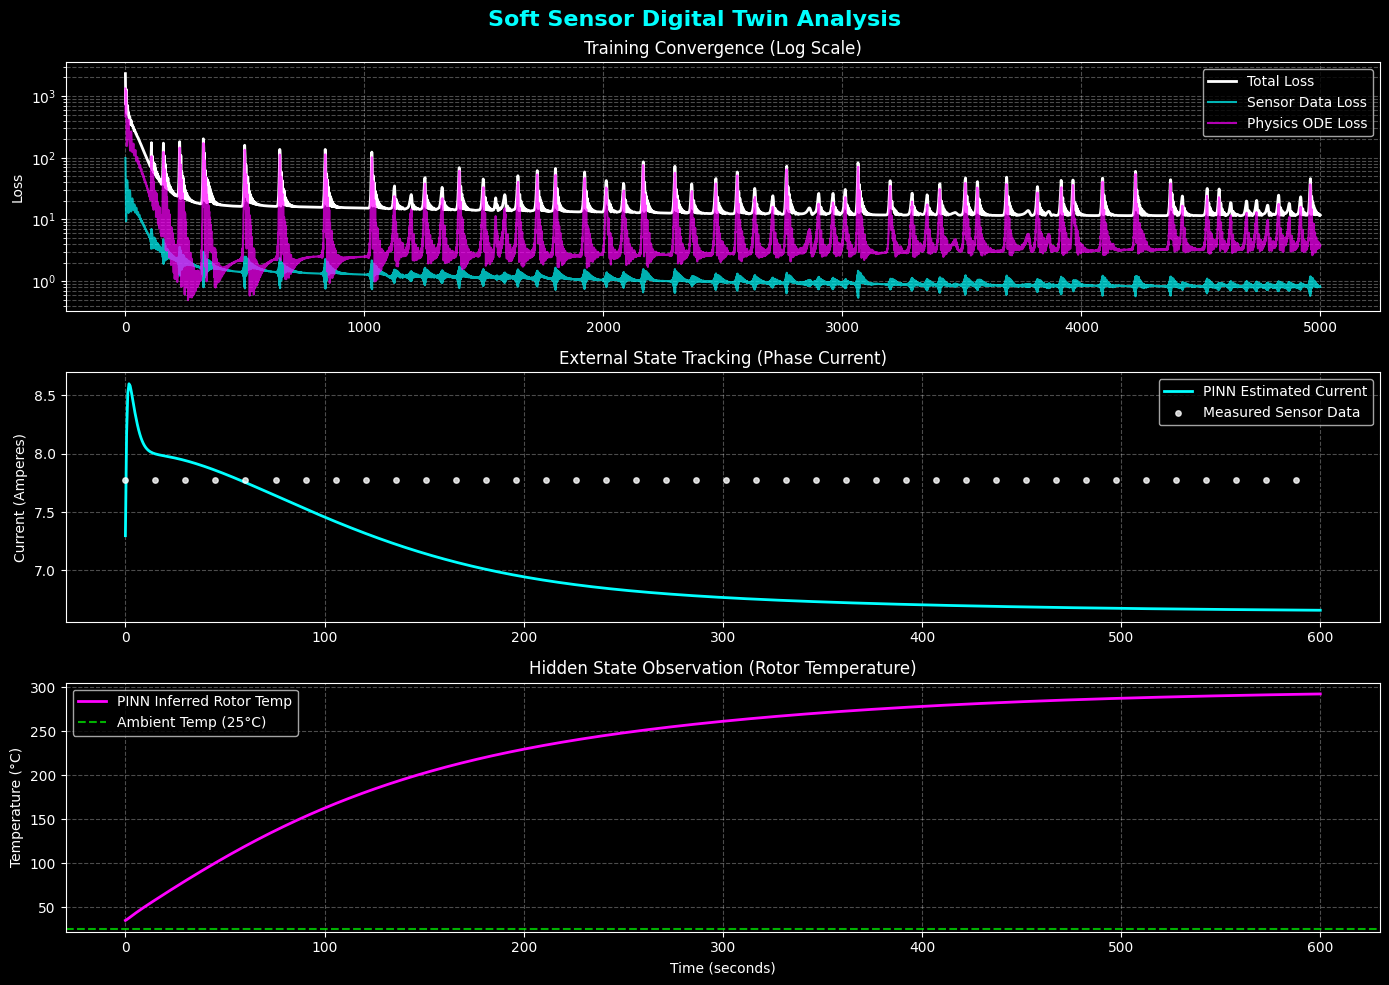

In [8]:
# Create comprehensive visualization
plt.style.use('dark_background')
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Soft Sensor Digital Twin Analysis', fontsize=16, fontweight='bold', color='cyan')

# 1. Convergence History
ax1 = plt.subplot(3, 1, 1)
ax1.plot(loss_history['total'], label='Total Loss', color='white', linewidth=2)
ax1.plot(loss_history['data'], label='Sensor Data Loss', color='cyan', alpha=0.7)
ax1.plot(loss_history['phys'], label='Physics ODE Loss', color='magenta', alpha=0.7)
ax1.set_yscale('log')
ax1.set_title('Training Convergence (Log Scale)', color='white')
ax1.set_ylabel('Loss', color='white')
ax1.grid(True, which="both", ls="--", alpha=0.3)
ax1.legend()

# 2. Current Tracking (Ammeter Observation)
ax2 = plt.subplot(3, 1, 2)
ax2.plot(t_collocation, i_pred_np, label='PINN Estimated Current', color='cyan', linewidth=2)
ax2.scatter(t_data[::5], i_measured[::5], color='white', label='Measured Sensor Data', 
           zorder=5, s=15, alpha=0.8)
ax2.set_title('External State Tracking (Phase Current)', color='white')
ax2.set_ylabel('Current (Amperes)', color='white')
ax2.grid(True, ls="--", alpha=0.3)
ax2.legend()

# 3. Temperature Observation (The Hidden State)
ax3 = plt.subplot(3, 1, 3)
ax3.plot(t_collocation, T_pred_np, label='PINN Inferred Rotor Temp', color='magenta', linewidth=2)
ax3.axhline(y=T_amb, color='lime', linestyle='--', label='Ambient Temp (25°C)', alpha=0.7)
ax3.set_title('Hidden State Observation (Rotor Temperature)', color='white')
ax3.set_xlabel('Time (seconds)', color='white')
ax3.set_ylabel('Temperature (°C)', color='white')
ax3.grid(True, ls="--", alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig('motor_observer_digital_twin.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'motor_observer_digital_twin.png'")
plt.show()

## 7. Detailed Analysis

In [9]:
# Analyze the temperature-dependent resistance
print("\n" + "="*60)
print("ELECTRO-THERMAL COUPLING ANALYSIS")
print("="*60)

# Calculate resistance at different temperatures
T_samples = [T_amb, T_pred_np.max(), T_pred_np.min()]
print("\nTemperature-Dependent Resistance:")
for T in T_samples:
    R = R0 * (1.0 + alpha * (T - T_amb))
    print(f"  T = {T:.2f}°C → R = {R:.4f} Ω (ΔR = {(R-R0)/R0*100:.2f}%)")

# Calculate power loss at different temperatures
print("\nOhmic Power Loss (at steady-state current):")
i_ss = i_measured[0]
for T in T_samples:
    R = R0 * (1.0 + alpha * (T - T_amb))
    P_loss = float((i_ss**2) * R)
    print(f"  T = {T:.2f}°C → P_loss = {P_loss:.2f} W")
    
# Calculate power loss at different temperatures
print("\nOhmic Power Loss (at steady-state current):")
i_ss = float(i_measured[0])  # Force the starting current to be a standard float
for T in T_samples:
    T_val = float(T)         # Force T to be a standard float
    R = R0 * (1.0 + alpha * (T_val - T_amb))
    P_loss = float((i_ss**2) * R)  # Force the final power calculation to be a standard float
    
    # Now the formatter will work perfectly!
    print(f"  T = {T_val:.2f}°C → P_loss = {P_loss:.2f} W")

# Calculate thermal time constant
tau_thermal = C_th * R_th
print(f"\nThermal Time Constant: {tau_thermal:.2f} seconds")
print(f"  (Time to reach ~63% of steady-state temperature)")

# Estimate steady-state temperature
R_ss = R0 * (1.0 + alpha * (float(T_pred_np.max()) - T_amb))
P_loss_ss = (i_ss**2) * R_ss
T_ss_estimated = T_amb + P_loss_ss * R_th
print(f"\nEstimated Steady-State Temperature: {float(T_ss_estimated):.2f}°C")
print(f"  (Based on power loss and thermal resistance)")


ELECTRO-THERMAL COUPLING ANALYSIS

Temperature-Dependent Resistance:
  T = 25.00°C → R = 1.2000 Ω (ΔR = 0.00%)
  T = 292.39°C → R = 2.4610 Ω (ΔR = 105.09%)
  T = 35.19°C → R = 1.2480 Ω (ΔR = 4.00%)

Ohmic Power Loss (at steady-state current):
  T = 25.00°C → P_loss = 72.59 W
  T = 292.39°C → P_loss = 148.88 W
  T = 35.19°C → P_loss = 75.50 W

Ohmic Power Loss (at steady-state current):
  T = 25.00°C → P_loss = 72.59 W
  T = 292.39°C → P_loss = 148.88 W
  T = 35.19°C → P_loss = 75.50 W

Thermal Time Constant: 125.00 seconds
  (Time to reach ~63% of steady-state temperature)

Estimated Steady-State Temperature: 397.19°C
  (Based on power loss and thermal resistance)


/tmp/ipykernel_16/412769808.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P_loss = float((i_ss**2) * R)
/tmp/ipykernel_16/412769808.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i_ss = float(i_measured[0])  # Force the starting current to be a standard float
